In [4]:
!pip install pandas matplotlib numpy scikit-learn seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [7]:
df = pd.read_csv("data (1).csv")
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


Basic EDA

In [8]:
df.shape

(2500, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


In [10]:
df.describe()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


In [11]:
df.isnull().sum()

Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64

Separate Features and Target

In [12]:
X = df.drop("Rain",axis=1)
y = df["Rain"]

Train Test Split

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
X_train

array([[-1.71263493,  0.69390068, -0.86861453, -0.70031358,  0.97294421],
       [ 1.56367137, -1.57319489, -0.48232553,  1.52129622,  0.69276499],
       [-1.00061791,  0.88162784,  0.12319085, -1.01742742,  1.59736206],
       ...,
       [-1.70586937, -1.68655365, -0.08128169,  0.14884272, -0.81276647],
       [-1.62871569, -1.57486904,  1.20427106,  1.00184127, -0.11237091],
       [ 1.47160549,  1.33450171, -1.28944369,  0.19130475,  1.65351719]],
      shape=(2000, 5))

In [25]:
y_test

1447    no rain
1114    no rain
1064       rain
2287    no rain
1537    no rain
         ...   
2375    no rain
1609    no rain
596        rain
84      no rain
2213    no rain
Name: Rain, Length: 500, dtype: object

In [26]:
df['Rain'] = df['Rain'].map({
    'no rain': 0,
    'rain': 1
})

In [28]:
print(df['Rain'].unique())

[1 0]


Feature Scaling

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Logistic Regression

In [16]:
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Prediction

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

Accuracy

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.932


Confusion Matrix

In [19]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[430  13]
 [ 21  36]]


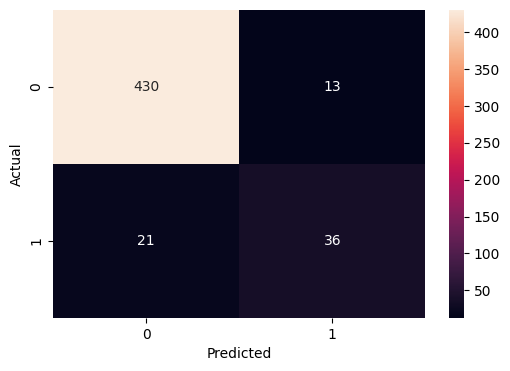

In [20]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     no rain       0.95      0.97      0.96       443
        rain       0.73      0.63      0.68        57

    accuracy                           0.93       500
   macro avg       0.84      0.80      0.82       500
weighted avg       0.93      0.93      0.93       500



ROC Curve

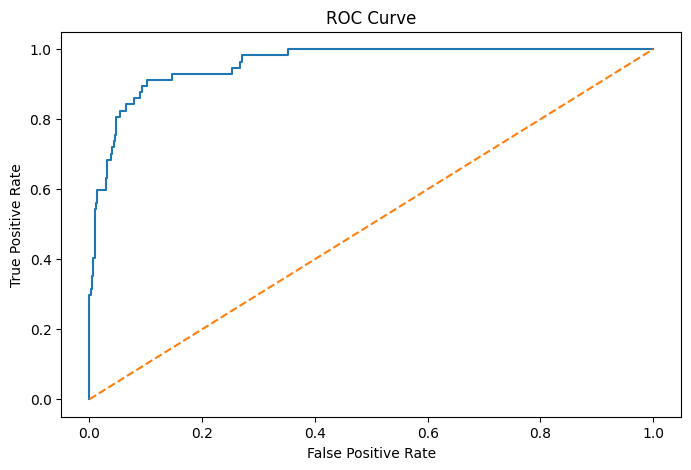

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob,pos_label='rain')

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

ROC-AUC Score

In [31]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9582986812403469


Feature Importance

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(importance)

       Feature  Coefficient
1     Humidity     2.569458
3  Cloud_Cover     2.308996
2   Wind_Speed     0.019656
4     Pressure    -0.029810
0  Temperature    -1.940104


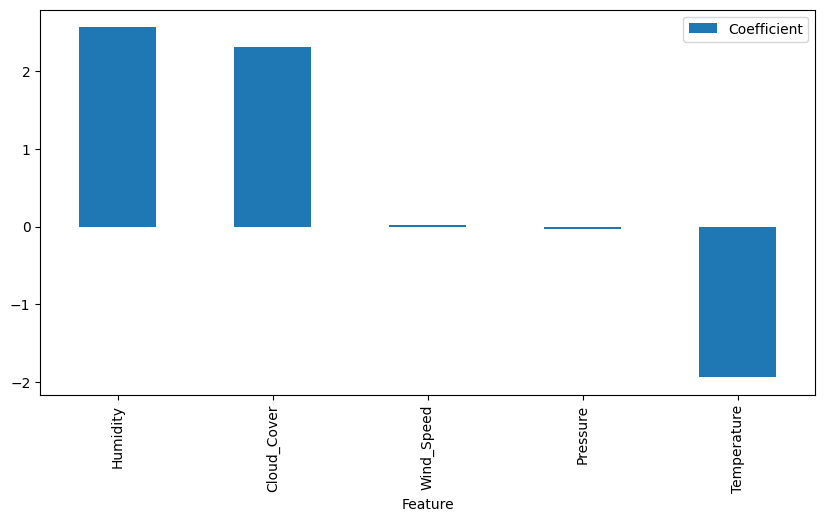

In [33]:
importance.plot(
    x="Feature",
    y="Coefficient",
    kind="bar",
    figsize=(10,5)
)

plt.show()

In [34]:
import pickle

# Save Logistic Regression Model
pickle.dump(
    model,
    open("rain_prediction_model.pkl", "wb")
)

# Save Scaler
pickle.dump(
    scaler,
    open("scaler.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully
